<h1>Chapter 7-Homework-Problem 5</h1>

<p>In this exercise, we will use logistic regression to analyze customer behavior and predict whether a customer will leave a company, called churn. We use a real-world dataset from IBM that is widely used in business analytics and machine learning.</p>

<p>A telecommunications company wants to understand why customers cancel their service. Each observation represents one customer.</p>

<p>The dependent variable is the churn and defined below:<br />
•	1 = Customer leaves<br />
•	0 = Customer stays</p>

<p>These explanatory variables help explain why customers leave and are defined below:</p>

<p>•	tenure – number of months the customer has stayed<br />
•	MonthlyCharges – monthly bill amount<br />
•	TotalCharges – total amount paid<br />
•	Contract – type of contract (month-to-month, one year, two year)<br />
•	InternetService – type of internet service<br />
•	PaymentMethod – how the customer pays<br />
•	SeniorCitizen – whether the customer is elderly</p>

<p>Please estimate the logistic regression for churn. Perform the analysis to determine what causes customers to leave this company. The dataset is Chapter_07-churn_data.csv</p>

First five observations:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMo

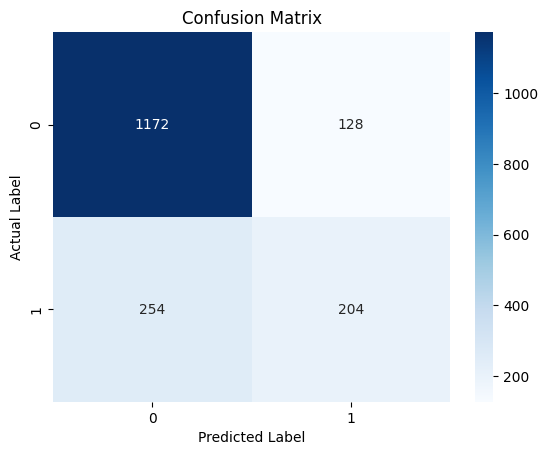


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1300
       Churn       0.61      0.45      0.52       458

    accuracy                           0.78      1758
   macro avg       0.72      0.67      0.69      1758
weighted avg       0.77      0.78      0.77      1758

Optimization terminated successfully.
         Current function value: 0.445201
         Iterations 7

Logit Model Summary:
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5274
Model:                          Logit   Df Residuals:                     5269
Method:                           MLE   Df Model:                            4
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                  0.2335
Time:                        11:17:22   Log-Likelihood:                -2348.0
converged:                       True   LL-Null:   

In [1]:
# ============================================
# Logistic Regression: Customer Churn Example
# ============================================

# --------------------------------------------
# Step 1: Import required libraries
# --------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report

import statsmodels.api as sm

# --------------------------------------------
# Step 2: Load the dataset
# --------------------------------------------

df = pd.read_csv('Chapter_07-churn_data.csv')

print("First five observations:")
print(df.head())

# --------------------------------------------
# Step 3: Data cleaning
# --------------------------------------------
# Convert TotalCharges to numeric (it may contain spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing values
df = df.dropna()

# Convert Churn to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# --------------------------------------------
# Step 4: Select variables
# --------------------------------------------
# Keep a simple set of variables for teaching clarity
df_model = df[[
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen',
    'Churn'
]]

# Define X and y
X = df_model[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]
y = df_model['Churn']

# --------------------------------------------
# Step 5: Split data into training and testing
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# --------------------------------------------
# Step 6: Estimate logistic regression (sklearn)
# --------------------------------------------
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# --------------------------------------------
# Step 7: Evaluate model performance
# --------------------------------------------
conf_matrix = metrics.confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(conf_matrix)

# --------------------------------------------
# Step 8: Visualize confusion matrix
# --------------------------------------------
plt.figure()
sns.heatmap(
    pd.DataFrame(conf_matrix),
    annot=True,
    fmt='g',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# --------------------------------------------
# Step 9: Classification report
# --------------------------------------------
target_names = ['No Churn', 'Churn']

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# --------------------------------------------
# Step 10: Estimate Logit model (statsmodels)
# --------------------------------------------
# Add constant for intercept
X_train_sm = sm.add_constant(X_train)

# Fit Logit model
logit_model = sm.Logit(
    y_train.astype(float),
    X_train_sm.astype(float)
).fit()

print("\nLogit Model Summary:")
print(logit_model.summary())
